Link to dataset : https://drive.google.com/file/d/1sbQ5WJ-KCPBrhT2YagtaARGoujCMpB8Q/view

# SA-2025 WEEK 3 GRADED ASSIGNMENT

> Spaceship Titanic

Predict which passengers are transported to an alternate dimension

![](https://www.gannett-cdn.com/-mm-/682bf77435754aee88576469063388a7d8b07c2a/c=0-150-1280-873/local/-/media/2017/02/01/Reno/RGJ/636215634914521096-image001.jpg?width=660&height=373&fit=crop&format=pjpg&auto=webp)


### <b>Description</b>

Welcome to the year 2912, where your data science skills are needed to solve a cosmic mystery. We've received a transmission from four lightyears away and things aren't looking good.

The Spaceship Titanic was an interstellar passenger liner launched a month ago. With almost 13,000 passengers on board, the vessel set out on its maiden voyage transporting emigrants from our solar system to three newly habitable exoplanets orbiting nearby stars.

While rounding Alpha Centauri en route to its first destination—the torrid 55 Cancri E—the unwary Spaceship Titanic collided with a spacetime anomaly hidden within a dust cloud. Sadly, it met a similar fate as its namesake from 1000 years before. Though the ship stayed intact, almost half of the passengers were transported to an alternate dimension!

### <b>Data description</b>

- Personal records for about two-thirds (~8700) of the passengers, to be used as training data.
- <code>PassengerId</code> - A unique Id for each passenger. Each Id takes the form gggg_pp where gggg indicates a group the passenger is travelling with and pp is their number within the group. People in a group are often family members, but not always.
- <code>HomePlanet</code> - The planet the passenger departed from, typically their planet of permanent residence.
- <code>CryoSleep</code> - Indicates whether the passenger elected to be put into suspended animation for the duration of the voyage. Passengers in cryosleep are confined to their cabins.
- <code>Cabin</code> - The cabin number where the passenger is staying. Takes the form deck/num/side, where side can be either P for Port or S for Starboard.
- <code>Destination</code> - The planet the passenger will be debarking to.
- <code>Age</code> - The age of the passenger.
- <code>VIP</code> - Whether the passenger has paid for special VIP service during the voyage.
- <code>RoomService, FoodCourt, ShoppingMall, Spa, VRDeck</code> - Amount the passenger has billed at each of the Spaceship Titanic's many luxury amenities.
- <code>Name</code> - The first and last names of the passenger.
- <code>Transported</code> - Whether the passenger was transported to another dimension. This is the target, the column you are trying to predict.


### <b>Algorithm Documentation</b> (Highly recommended!)
- <code>Logistic Regression</code> : https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html
- <code>SVM</code> : https://scikit-learn.org/stable/modules/svm.html
Confusion Matrix : https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html
- <code>Plot Confusion Matrix</code> : https://scikit-learn.org/stable/modules/generated/sklearn.metrics.plot_confusion_matrix.html
- <code>ROC_AUC Score</code> : https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_auc_score.html#sklearn.metrics.roc_auc_score
- <code>Classification Report</code> : https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html
- <code>Label Encoder</code> : https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.LabelEncoder.html
- <code>Label Binarizer</code> : https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.LabelBinarizer.html
- <code>Standard Scaler</code> : https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html
- <code>Cross Val Score</code> : https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html

# <span><h1 style = "font-family: garamond; font-size: 40px; font-style: normal; letter-spcaing: 3px; background-color: #f6f5f5; color :#fe346e; border-radius: 100px 100px; text-align:center">Install Required Libraries</h1></span>

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.svm import SVC
from sklearn.metrics import (confusion_matrix, classification_report, roc_auc_score, accuracy_score, ConfusionMatrixDisplay,RocCurveDisplay)




#### Read the data

In [50]:
data= pd.read_csv("/data.csv")

#### Check the shape of data. It should be  (8693, 14)

In [51]:
print(data.shape)

(8693, 14)


#### Apply describe on dataframe

In [52]:
print(data.describe())

               Age   RoomService     FoodCourt  ShoppingMall           Spa  \
count  8693.000000   8693.000000   8693.000000   8693.000000   8693.000000   
mean     28.728517    220.009318    448.434027    169.572300    304.588865   
std      14.355438    660.519050   1595.790627    598.007164   1125.562559   
min       0.000000      0.000000      0.000000      0.000000      0.000000   
25%      20.000000      0.000000      0.000000      0.000000      0.000000   
50%      27.000000      0.000000      0.000000      0.000000      0.000000   
75%      37.000000     41.000000     61.000000     22.000000     53.000000   
max      79.000000  14327.000000  29813.000000  23492.000000  22408.000000   

             VRDeck  
count   8693.000000  
mean     298.261820  
std     1134.126417  
min        0.000000  
25%        0.000000  
50%        0.000000  
75%       40.000000  
max    24133.000000  


#### Check if there any null value in the dataset.

In [53]:
print(data.isnull().sum())

PassengerId     0
HomePlanet      0
CryoSleep       0
Cabin           0
Destination     0
Age             0
VIP             0
RoomService     0
FoodCourt       0
ShoppingMall    0
Spa             0
VRDeck          0
Name            0
Transported     0
dtype: int64


#### Number continuous and categorical features

In [54]:
continious_features= data.select_dtypes(include=["int64",  "float64"]).columns
categorical_features= data.select_dtypes(include=["object",  "bool"]).columns
print("Continious features")
print(list(continious_features))
print("Categorical features")
print(list(categorical_features))

Continious features
['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
Categorical features
['PassengerId', 'HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'VIP', 'Name', 'Transported']


#### Unique values

In [55]:
for col in categorical_features:
  print(col, data[col].nunique())

PassengerId 8693
HomePlanet 3
CryoSleep 2
Cabin 6560
Destination 3
VIP 2
Name 8473
Transported 2


<code>Note: If we apply one-hot-encoding to a categorical feature with many unique values, </code>
- Number of columns will be high
- Time required for training a model will be high
- We may not get usefull insights about the data

<code>This is the reason we are droping the features with more unique values.</code>


#### Drop the features

In [56]:
drop_cols= []
for col in categorical_features:
  if data[col].nunique()> 25:
    drop_cols.append(col)

df= data.drop(columns=drop_cols)
print(df.shape)

(8693, 11)


#### One Hot Encoding

In [57]:
df= pd.get_dummies(df, drop_first= True)
print(df.shape)


(8693, 13)


#### Changing bool columns to 0,1

In [58]:
## ======== Run this code(Don't change any code)======== ##

df['CryoSleep'] = df['CryoSleep'].astype(int)
df['VIP'] = df['VIP'].astype(int)
df['Transported'] = df['Transported'].astype(int)

df.head()

## ======== Run this code(Don't change any code)======== ##


,CryoSleep,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,HomePlanet_Europa,HomePlanet_Mars,Destination_Cygnus,Destination_Virgo
0,0,39,0,0,0,0,0,0,0,True,False,False,False
1,0,24,0,109,9,25,549,44,1,False,False,False,False
2,0,58,1,43,3576,0,6715,49,0,True,False,False,False
3,0,33,0,0,1283,371,3329,193,0,True,False,False,False
4,0,16,0,303,70,151,565,2,1,False,False,False,False


#### Split the data into train and test

In [59]:
X= df.drop("Transported", axis=1)
Y= df["Transported"]

X_train, X_test, Y_train, Y_test= train_test_split(X, Y, test_size= 0.15, random_state= 2022)

In [60]:
print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape)

(7389, 12)
(1304, 12)
(7389,)
(1304,)


#### Scale the data using Standard Scaler

In [61]:
scaler= StandardScaler()
X_train= scaler.fit_transform(X_train)
X_test= scaler.fit_transform(X_test)

## <b>Logistic Regression</b>
#### Use default parameters unless mentioned

In [62]:
lr= LogisticRegression()
lr.fit(X_train, Y_train)

LogisticRegression()

#### Plot confusion matrix

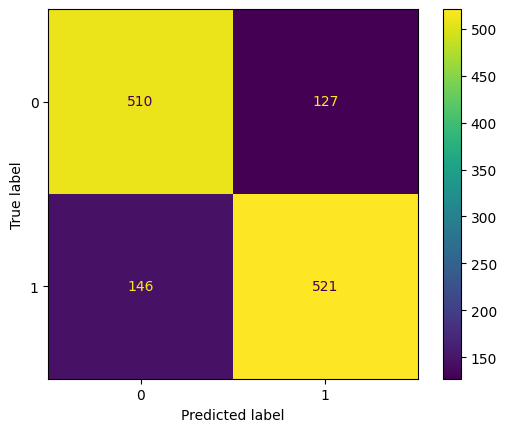

In [63]:
pred= lr.predict(X_test)
confusion_mat= confusion_matrix(Y_test, pred)
display= ConfusionMatrixDisplay(confusion_matrix=confusion_mat)
display.plot()
plt.show()

#### Print classification report

In [64]:
print(classification_report(Y_test, pred))

              precision    recall  f1-score   support

           0       0.78      0.80      0.79       637
           1       0.80      0.78      0.79       667

    accuracy                           0.79      1304
   macro avg       0.79      0.79      0.79      1304
weighted avg       0.79      0.79      0.79      1304



#### Print accuracy score

In [65]:
print(accuracy_score(Y_test, pred))

0.7906441717791411


#### Print ROC-AUC score

In [66]:
print(roc_auc_score(Y_test, pred))

0.790868694381224


#### Plot ROC-AUC Curve

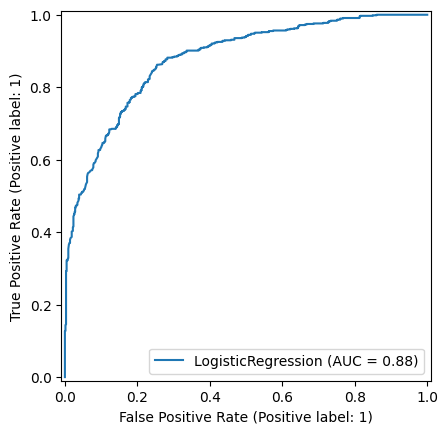

In [67]:
RocCurveDisplay.from_estimator(lr, X_test, Y_test)

#### Cross validation

In [68]:
scores= cross_val_score(lr, X, Y, cv=5)
print(scores)
print(scores.mean())


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

[0.78550891 0.78723404 0.77975848 0.78365938 0.79746835]
0.7867258341268576


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## <b>SVM</b>
#### Use default parameters unless mentioned

In [69]:
svm= SVC(probability=True)
svm.fit(X_train, Y_train)

SVC(probability=True)

#### Plot confusion matrix

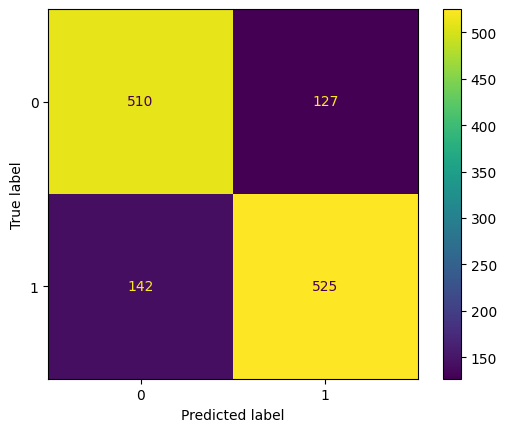

In [70]:
pred= svm.predict(X_test)
confusion_mat= confusion_matrix(Y_test, pred)
display= ConfusionMatrixDisplay(confusion_matrix=confusion_mat)
display.plot()
plt.show()

#### Print classification report

In [71]:
print(classification_report(Y_test, pred))

              precision    recall  f1-score   support

           0       0.78      0.80      0.79       637
           1       0.81      0.79      0.80       667

    accuracy                           0.79      1304
   macro avg       0.79      0.79      0.79      1304
weighted avg       0.79      0.79      0.79      1304



#### Print accuracy score

In [72]:
print(accuracy_score(Y_test, pred))

0.7937116564417178


#### Print ROC-AUC score

In [73]:
print(roc_auc_score(Y_test, pred))

0.793867195130849


#### Plot ROC-AUC curve

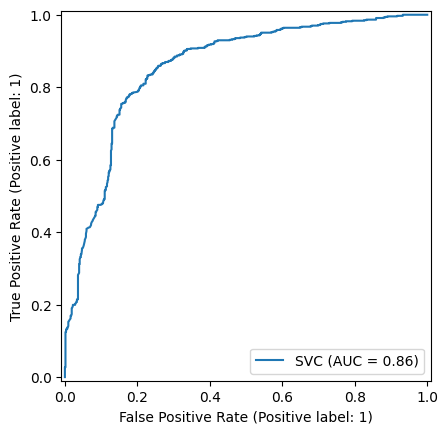

In [74]:
RocCurveDisplay.from_estimator(svm, X_test, Y_test)


#### Cross validation

In [75]:
scores= cross_val_score(svm, X, Y, cv=5)
print(scores)
print(scores.mean())

[0.76998275 0.77170788 0.79010926 0.80034522 0.7986191 ]
0.7861528423607606


# Congratulations! Assignment Completed!